# Die Array-gestützte Liste

## Agenda

1. Der **abstrakte Datentyp** (ADT) „Liste”
2. Eine **Datenstruktur** „Liste”
3. Unsere Listen-API
4. Erste Schritte
5. NumPy-Arrays
6. Die Datenstruktur `ArrayList`
7. Laufzeitanalyse

## 1. Der abstrakte Datentyp (ADT)

Ein **abstrakter Datentyp (ADT)** definiert ein *konzeptionelles Modell* dafür, wie Daten gespeichert und abgerufen werden können.

Ein **Listen-ADT** ist ein Datencontainer, in dem:

- Werte in einer *Sequenz* angeordnet sind,
- jeder Wert höchstens einen vorhergehenden und einen nachfolgenden Wert hat,
- ein bestimmter Wert mehr als einmal in einer Liste vorkommen kann.

Andere gängige ADTs (von denen wir einige später näher betrachten werden) sind:

- Stapel
- Warteschlangen
- Prioritätswarteschlangen
- Zuordnungen
- Graphen

## 2. Eine Listen-**Datenstruktur**

Eine **Listen-Datenstruktur** ist eine *konkrete Implementierung* der Listen-ADT in einer Programmiersprache, die zusätzlich zur Einhaltung der Grundvoraussetzungen der ADT in der Regel auch folgende Operationen unterstützt:

- Zugriff auf Werte in der Liste anhand ihrer Position (Index)
- Anhängen und Einfügen neuer Werte in die Liste
- Entfernen von Werten aus der Liste

Die Implementierung einer Datenstruktur basiert in der Regel auf einfacheren, konstituierenden Datentypen (z. B. den von der Sprache angebotenen „primitiven” Typen), deren Auswahl sich auf die Laufzeitkomplexität der genannten Operationen auswirken kann.

## 3. Die Listen-API

Die Operationen, die wir in unsere Listendatenstrukturen integrieren werden, basieren auf den [common](https://docs.python.org/3.6/library/stdtypes.html#common-sequence-operations) und [mutable](https://docs.python.org/3.6/library/stdtypes.html#mutable-sequence-types) Sequenzoperationen basieren, die von der Python-Bibliothek definiert sind.

In [1]:
class List:        
    ### subscript-based access ###
    
    def __getitem__(self, idx):
        """Implements `x = self[idx]`"""
        pass

    def __setitem__(self, idx, value):
        """Implements `self[idx] = x`"""
        pass

    def __delitem__(self, idx):
        """Implements `del self[idx]`"""
        pass
    
    ### stringification ###
            
    def __repr__(self):
        """Supports inspection"""
        return '[]'
    
    def __str__(self):
        """Implements `str(self)`"""
        return '[]'

    ### single-element manipulation ###
    
    def append(self, value):
        pass
    
    def insert(self, idx, value):
        pass
    
    def pop(self, idx=-1):
        pass
    
    def remove(self, value):
        pass
    
    ### predicates (T/F queries) ###
    
    def __eq__(self, other):
        """Implements `self == other`"""
        return True

    def __contains__(self, value):
        """Implements `val in self`"""
        return True
    
    ### queries ###
    
    def __len__(self):
        """Implements `len(self)`"""
        return len(self.data)
    
    def min(self):
        pass
    
    def max(self):
        pass
    
    def index(self, value, i, j):
        pass
    
    def count(self, value):
        pass

    ### bulk operations ###

    def __add__(self, other):
        """Implements `self + other_array_list`"""
        return self
    
    def clear(self):
        pass
    
    def copy(self):
        pass

    def extend(self, other):
        pass

    ### iteration ###
    
    def __iter__(self):
        """Supports iteration (via `iter(self)`)"""
        pass

## 4. Probieren wir das mal aus
Als erste bauen wir eine sehr einfache Liste mit *einem* Element.

In [2]:
class List:
    def append(self, value):
        self.val = value
    
    def __getitem__(self, idx):
        """Implements `x = self[idx]`"""
        return self.val

    def __setitem__(self, idx, value):
        """Implements `self[idx] = x`"""
        self.val = value
    
    def __repr__(self):
        """Supports inspection"""
        return f'[{repr(self.val)}]'

In [3]:
l = List()
l.append(42)
l

[42]

In [4]:
l[0]

42

In [5]:
l[0] = 331

In [6]:
l[500]

331

In [7]:
l

[331]

Natürlich sollte unsere Liste mehr als ein Datenelement aufnehmen können. Die naheliegendste Lösung ist ein `array`.

## 5. NumPy-Arrays

Python verfügt nicht über einen eingebauten Array-Typ. Stattdessen verwenden wir die Array-Implementierung aus dem [NumPy-Paket für wissenschaftliches Rechnen](https://numpy.org/doc/stable/user/absolute_beginners.html).

Um ein NumPy-Array der Größe N zu erstellen, können wir folgendes tun:

In [8]:
import numpy as np

N = 10
arr = np.empty(N, dtype=object)

Die Angabe `dtype=object` bedeutet, dass wir das Array verwenden möchten, um Verweise auf beliebige Python-Objekte zu speichern. Die Funktion `empty` erzeugt ein Array der angegebenen Größe, lässt jedoch alle Elemente uninitialisiert.

Jetzt können wir die Elemente im Array wie gewohnt per Index bearbeiten.

In [9]:
for i in range(10):
    arr[i] = 2**i

arr[5]  = 'hello'
arr[9] = 'world'

In [10]:
arr

array([1, 2, 4, 8, 16, 'hello', 64, 128, 256, 'world'], dtype=object)

Obwohl NumPy Funktionen zum Anhängen, Einfügen und Löschen von Elementen in Arrays bereitstellt, werden wir keine davon verwenden. Der Grund: Jede dieser Funktionen erstellt ein neues Array, kopiert die Elemente hinein und löscht anschließend das ursprüngliche Array. Das ist sowohl speicher- als auch zeitaufwändig!  
Stattdessen implementieren wir diese Operationen selbst – und optimieren sie, wo möglich – innerhalb unserer eigenen Listenklasse.

## 6. Die `ArrayListe` Datenstruktur

Unsere Listendatenstruktur verwendet ein NumPy-Array als internen Datenspeicher. Dieses Array hat zunächst eine feste Größe, aber wenn der Liste weitere Elemente hinzugefügt werden, kann es notwendig sein, ein neues, größeres Array zu erstellen und die Elemente zu kopieren. Jedes Mal, wenn wir ein neues Array anlegen, *verdoppeln wir die Kapazität des ursprünglichen Arrays* – das mag jetzt willkürlich wirken, aber später werden wir sehen, warum dieser Schritt entscheidend ist!

In [11]:
import numpy as np

class ArrayList:
    def __init__(self):
        self.data = np.empty(1, dtype=object)
        self.size = 0


    def append(self, value):
        if self.size == len(self.data): # if the backing array is full
            ndata = np.empty(len(self.data)*2, dtype=object) # create a new one with double the capacity
            for i in range(len(self.data)): # copy elements over
                ndata[i] = self.data[i]
            self.data = ndata # replace our backing store with the new array
            
        self.data[self.size] = value
        self.size += 1


    def __getitem__(self, idx):
        """Implements `x = self[idx]`"""
        assert isinstance(idx, int), 'Index must be an integer'
        if idx < 0:
            idx += self.size
        if idx < 0 or idx >= self.size:
            raise IndexError('list index out of range')
        return self.data[idx]
    

    def __setitem__(self, idx, value):
        """Implements `self[idx] = x`"""
        assert isinstance(idx, int), 'Index must be an integer'
        if idx < 0:
            idx += self.size
        if idx < 0 or idx >= self.size:
            raise IndexError('list index out of range')
        self.data[idx] = value
        

    def __delitem__(self, idx):
        """Implements `del self[idx]`"""
        assert isinstance(idx, int), 'Index must be an integer'
        if idx < 0:
            idx += self.size
        if idx < 0 or idx >= self.size:
            raise IndexError('list index out of range')
        for i in range(idx, self.size-1):
            self.data[i] = self.data[i+1]
        self.size -= 1
        
    
    def __len__(self):
        """Implements `len(self)`"""
        return self.size
    
    
    def __repr__(self):
        """Supports inspection"""
        return '[' + ','.join(repr(self.data[i]) for i in range(self.size)) + ']'

In [12]:
l = ArrayList()
for x in range(10):
    l.append(x)
l

[0,1,2,3,4,5,6,7,8,9]

In [13]:
l[0] = 'hello'
l[-1] = 'world'
l

['hello',1,2,3,4,5,6,7,8,'world']

In [14]:
l[2] = 'two'
l[-3] = 'seven'
l

['hello',1,'two',3,4,5,6,'seven',8,'world']

In [15]:
del l[5]
l

['hello',1,'two',3,4,6,'seven',8,'world']

In [16]:
del l[0]
del l[-1]
l

[1,'two',3,4,6,'seven',8]

In [17]:
len(l)

7

## 7. Laufzeitanalyse

- Indexierung: Erinnern wir uns daran, dass das Indexieren eines Arrays eine $O(1)$-Operation ist. Das bedeutet, dass sowohl `__getitem__` als auch `__setitem__` eine Laufzeit von $O(1)$ haben.

- Suche (unsortiert): In einer unsortierten, array-basierten Liste ist eine lineare Suche erforderlich, was $O(N)$ entspricht.

- Suche (sortiert): In einer sortierten, array-basierten Liste kann die binäre Suche verwendet werden, was $O(\log N)$ entspricht.

- Löschen: Der schlechteste Fall für `__delitem__` tritt auf, wenn das Element am Index 0 gelöscht wird. Dann müssen $N-1$ Elemente verschoben werden, was $O(N)$ ist.

- Anhängen (append):

   - Ist das zugrunde liegende Array nicht voll, wird der Wert einfach eingefügt — das ist $O(1)$ (günstig!).
   
   - Ist das Array voll, müssen alle Elemente zusammen mit dem neuen Wert in ein neues Array kopiert werden — das ist $O(N)$ (teuer!). Eine naive Betrachtung würde darauf schließen lassen, dass das Anhängen $O(N)$ ist.
   
   - Aber das Kopieren in neue Arrays passiert nur selten! Eine genauere Analyse zeigt: Die gelegentlich teure Operation wird durch viele günstige, konstante Zeitoperationen ausgeglichen. Können wir die Zeit für die teuren Operationen so auf die vielen günstigen verteilen (*amortisieren*), dass das Anhängen im Durchschnitt besser als $O(N)$ ist?
   
       - Angenommen, wir starten mit einem Array der Größe 1 und verdoppeln jedes Mal, wenn wir die Kapazitätsgrenze erreichen. Betrachten wir die Kosten (Anzahl der Kopiervorgänge), wenn wir der Liste fortlaufend Elemente anhängen:
       
               Append #:   1  2  3  4  5  6  7  8   9  10  11  12  13  14  15  16  17  18  19  20 ...
               Kapazität:  1  2  4  4  8  8  8  8  16  16  16  16  16  16  16  16  32  32  32  32 ...
               Kosten:     1  2  3  1  5  1  1  1   9   1   1   1   1   1   1   1  17   1   1   1 ...
               
       - Versuchen wir, die Amortisationsfrage direkt zu beantworten: Bei den günstigen Operationen „sparen“ wir ein paar Extra-Credits, die wir bei den teuren Operationen „ausgeben“. Gibt es eine Anzahl Credits, die das immer ausgleicht?
       
           - Tatsächlich funktioniert es, wenn wir jeder Operation einen Aufwand von 3 zuweisen und entsprechend sparen oder ausgeben:
       
                   Append #:             1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 ...
                   Tatsächliche Kosten:  1   2   3   1   5   1   1   1   9   1   1   1   1   1   1   1  17   1   1   1 ...
                   -------------------------------------------------------------------------------------------------------
                   Credits gespart/ausgegeben: +2  +1   0  +2  -2  +2  +2  +2  -6  +2  +2  +2  +2  +2  +2  +2 -14  +2  +2  +2 ...
                   Zugeschriebene Kosten:      3   3   3   3   3   3   3   3   3   3   3   3   3   3   3   3   3   3   3   3 ...
                   Credits angespart:           2   3   3   5   3   5   7   9   3   5   7   9  11  13  15  17   3   5   7   9 ...

           - Die 3 Credits für das Einfügen eines Elements an Position $i$ werden so verwendet:
           
               - Einer für das Kopieren des Elements selbst ins Array
               - Einer für das Verschieben des Elements in ein neues Array beim ersten Mal
               - Einer für das Verschieben eines Elements an Position $i-2^j$ (wobei $2^j$ die größte Zweierpotenz kleiner als $i$ ist) in ein neues Array
               
           Wir schließen daraus, dass das Anhängen **amortisiert $O(1)$** ist.
                        
       - Mathematisch: Die Kosten der $i$-ten Anhänge-Operation:
       
         $$c_i = \begin{cases} i &\text{wenn $i-1$ eine Zweierpotenz ist} \\ 1 & \text{ansonsten} \end{cases}$$
         
         Für die Gesamtkosten von $N$ aufeinanderfolgenden Appends gilt:
         
         $$\sum_{i=1}^N c_i \le N + \sum_{j=0}^{\lfloor \log_2 N \rfloor} 2^j$$
         
         Die rechte Summe ist eine geometrische Reihe, die sich wie folgt auflöst:
         
         $$\sum_{j=0}^{n} r^j = \frac{1-r^{n+1}}{1-r}$$
         
         Für $r=2$ ergibt sich $\sum_{j=0}^{\lfloor \log_2 N \rfloor} 2^j = 2N - 1$, also:
         
         $$\sum_{i=1}^N c_i \le 3N - 1$$

### Nicht verdoppeln?

Was wäre die amortisierte Laufzeit für das Anhängen, wenn wir das Array bei Bedarf nur um einen konstanten Wert erweitern und nicht verdoppeln würden?

In [18]:
import numpy as np

class ArrayList:
    def __init__(self):
        self.data = np.empty(1, dtype=object)
        self.size = 0


    def append(self, value, doubling=True):
        if self.size == len(self.data):
            if doubling:
                ndata = np.empty(len(self.data)*2, dtype=object)
            else:
                ndata = np.empty(len(self.data)+1000, dtype=object)
            for i in range(len(self.data)):
                ndata[i] = self.data[i]
            self.data = ndata
            
        self.data[self.size] = value
        self.size += 1

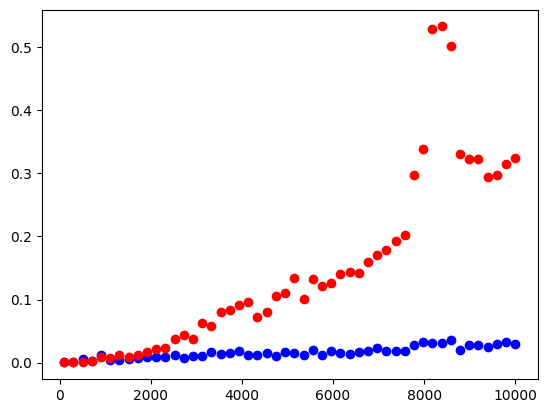

In [19]:
import timeit
import matplotlib.pyplot as plt

ns = np.linspace(100, 10_000, 50, dtype=int)
ts1 = [timeit.timeit(stmt=f'for _ in range({n}): lst.append(None, doubling=True)', 
                     setup='lst = ArrayList()',
                     globals=globals(), 
                     number=10)
       for n in ns]
ts2 = [timeit.timeit(stmt=f'for _ in range({n}): lst.append(None, doubling=False)', 
                     setup='lst = ArrayList()',
                     globals=globals(), 
                     number=10)
       for n in ns]

plt.plot(ns, ts1, 'ob')
plt.plot(ns, ts2, 'or');

Nein! Wir werden es nicht beweisen, aber wenn das Array bei Bedarf nur um einen konstanten Wert erweitert wird, ergibt sich ein Gesamtkostenaufwand von $O(N^2)$ für $N$ Anhänge. Das bedeutet eine amortisierte Laufzeit von $O(N)$ pro Anfügeoperation. Das ist definitiv nicht gut!